# ROB Tables - Quick Inspection (processed_export)

This notebook loads the latest `processed_export_*.json`, builds `df_tables`, and lets you print each table with `show_table(index)`.

Each table entry keeps the markdown and PDF paths close at hand for quick manual verification.

# Data preparation

## Imports and loads

In [15]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display

EXPORTS_DIR = Path('../paper_pipeline_data/exports')
processed_files = sorted(EXPORTS_DIR.glob('processed_export_*.json'))
if not processed_files:
    raise FileNotFoundError('No processed_export_*.json found in paper_pipeline_data/exports')

proc_file = processed_files[-1]
print('Using:', proc_file)
with open(proc_file, 'r', encoding='utf-8') as f:
    processed = json.load(f)

print(f'Loaded {len(processed)} documents')

Using: ../paper_pipeline_data/exports/processed_export_1778938206.json
Loaded 134 documents


## Parsing Data

In [16]:
rows = []

for doc in processed:
    doi = doc.get('paper_id') or doc.get('pmcid') or doc.get('paper') or doc.get('doi')
    md_path = doc.get('md') or doc.get('md_path')
    pdf_path = doc.get('pdf_path')
    sections = doc.get('sections', []) or []

    for sec in sections:
        heading = sec.get('heading')
        tables = sec.get('tables', []) or []
        for table_index, table in enumerate(tables):
            header = table.get('header') or []
            table_rows = table.get('rows') or []
            rows.append({
                'DOI': doi,
                'Section': heading,
                'Table_Index': table_index,
                'MD_Path': md_path,
                'PDF_Path': pdf_path,
                'Header': header,
                'Preview_Row': table_rows[0] if table_rows else [],
                'Rows': table_rows,
            })

df_tables = pd.DataFrame(rows)
print(f'Total extracted tables: {len(df_tables)}')
display(df_tables[['DOI', 'Section', 'Table_Index', 'MD_Path', 'PDF_Path', 'Header', 'Preview_Row']].head(50))

Total extracted tables: 609


,DOI,Section,Table_Index,MD_Path,PDF_Path,Header,Preview_Row
0,10.1186/s13601-019-0278-3,Results,0,paper_pipeline_data/md/PMC6706894.md,paper_pipeline_data/pdf/PMC6706894.pdf,"[Study, Type of study, Patients, Control group]",[I. Psychiatric comorbidity in CU patients (st...
1,10.1186/s13601-019-0278-3,Results,1,paper_pipeline_data/md/PMC6706894.md,paper_pipeline_data/pdf/PMC6706894.pdf,"[, CU patients, CU patients with psychiatric c...","[Juhlin [18], , ]"
2,10.1186/s13601-019-0278-3,Results,2,paper_pipeline_data/md/PMC6706894.md,paper_pipeline_data/pdf/PMC6706894.pdf,"[, Chronic urticaria patients, Control individ...","[All, With psychiatric comorbidity, All]"
3,10.1186/s13601-019-0278-3,Results,3,paper_pipeline_data/md/PMC6706894.md,paper_pipeline_data/pdf/PMC6706894.pdf,"[DSM-5 classification, PatientsN/all CU patien...","[Prevalence per study, Pooled prevalence (%), ..."
4,10.1002/clt2.12283,RESULTS,0,paper_pipeline_data/md/PMC10349543.md,paper_pipeline_data/pdf/PMC10349543.pdf,"[First author Year (Ref.), Sample size (T/C), ...","[Gerasimov 2010, 43/47, 25.6 ± 7.7/24.1 ± 6.3 ..."
5,10.1002/clt2.12283,RESULTS,1,paper_pipeline_data/md/PMC10349543.md,paper_pipeline_data/pdf/PMC10349543.pdf,"[Author, year, Randomization process, Deviatio...","[Gerasimov 2010, Low risk, Low risk, Low risk,..."
6,10.1002/clt2.12283,Study selection,0,paper_pipeline_data/md/PMC10349543.md,paper_pipeline_data/pdf/PMC10349543.pdf,"[First author Year (Ref.), Sample size (T/C), ...","[Gerasimov 2010, 43/47, 25.6 ± 7.7/24.1 ± 6.3 ..."
7,10.1002/clt2.12283,Risk of bias in the included studies,0,paper_pipeline_data/md/PMC10349543.md,paper_pipeline_data/pdf/PMC10349543.pdf,"[Author, year, Randomization process, Deviatio...","[Gerasimov 2010, Low risk, Low risk, Low risk,..."
8,10.3389/falgy.2024.1499406,Methods and analysis,0,paper_pipeline_data/md/PMC11694227.md,paper_pipeline_data/pdf/PMC11694227.pdf,"[No., Search terms]","[#1, MeSH terms: “rhinitis, allergic”]"
9,10.3389/falgy.2024.1499406,Databases and search strategies,0,paper_pipeline_data/md/PMC11694227.md,paper_pipeline_data/pdf/PMC11694227.pdf,"[No., Search terms]","[#1, MeSH terms: “rhinitis, allergic”]"


## show_table() method

In [17]:
def show_table(index, _df):
    if index < 0 or index >= len(_df):
        print('Index out of range')
        return

    record = _df.iloc[index]
    print('DOI:', record['DOI'])
    print('Section:', record['Section'])
    print('MD Path:', record['MD_Path'])
    print('PDF Path:', record['PDF_Path'])

    headers = record['Header'] or []
    table_rows = record['Rows'] or []
    if not headers or not table_rows:
        print('No table data available')
        return

    display(pd.DataFrame(table_rows, columns=headers))

if len(df_tables):
    show_table(7, df_tables)
else:
    print('No tables to show')

DOI: 10.1002/clt2.12283
Section: Risk of bias in the included studies
MD Path: paper_pipeline_data/md/PMC10349543.md
PDF Path: paper_pipeline_data/pdf/PMC10349543.pdf


,"Author, year",Randomization process,Deviation from intended interventions,Missing outcome data,Measurement of the outcome,Selection of the reported result,Overall
0,Gerasimov 2010,Low risk,Low risk,Low risk,Some concerns,Some concerns,Some concerns
1,Wu 2011,Low risk,Low risk,Low risk,Low risk,Low risk,Low risk
2,Han 2012,Low risk,Low risk,Low risk,Some concerns,Low risk,Some concerns
3,Wang 2015,Low risk,Low risk,Low risk,Low risk,Low risk,Low risk
4,Navarro‐López 2017,Some concerns,Low risk,Low risk,Some concerns,Low risk,Some concerns
5,Plummer 2019,Low risk,Some concerns,Low risk,Low risk,Low risk,Some concerns
6,Jeong 2020,Some concerns,Some concerns,Low risk,Some concerns,Low risk,Some concerns
7,Ahn 2020,Some concerns,Low risk,Low risk,Some concerns,Low risk,Some concerns
8,Cukrowska 2021,Some concerns,Low risk,Low risk,Some concerns,Low risk,Some concerns


# Table count in sections histogram

Sections found: 199


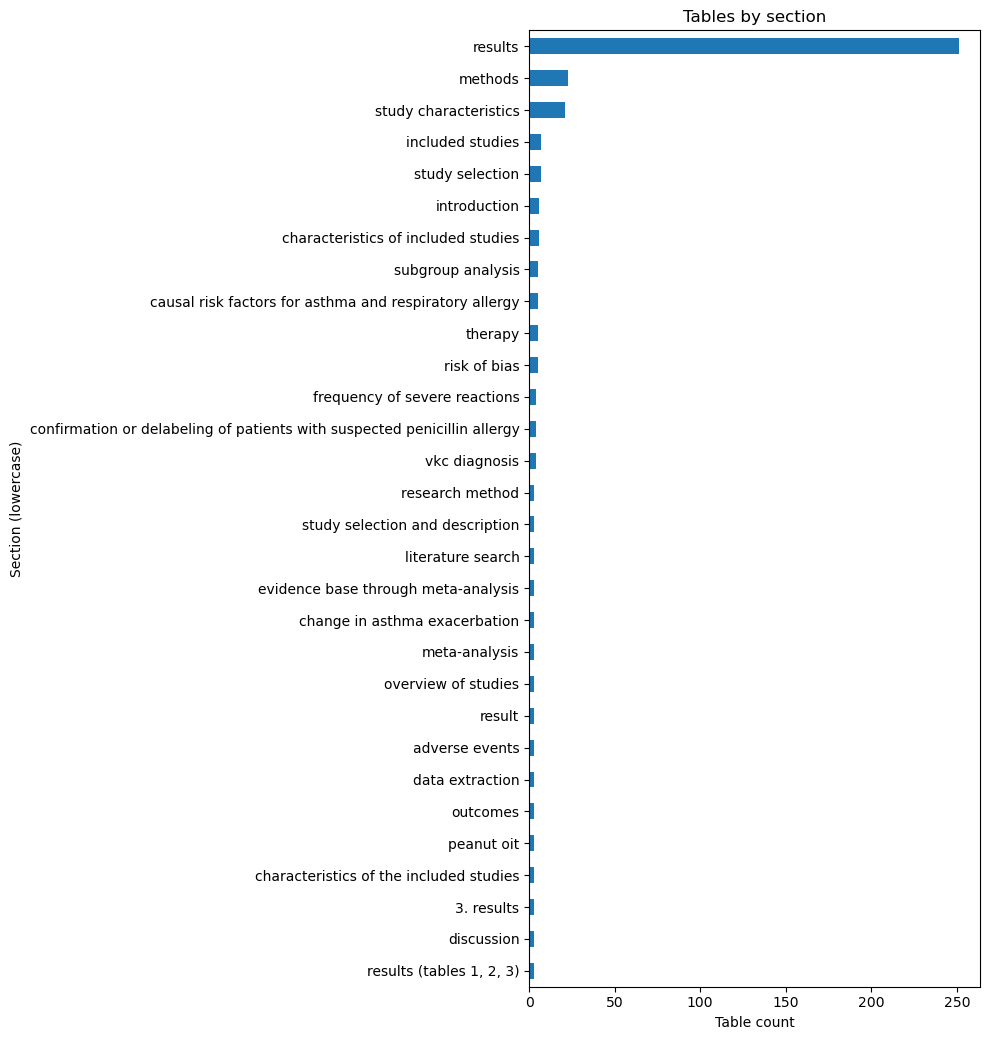

In [18]:
import matplotlib.pyplot as plt

section_counts = (
    df_tables['Section']
    .fillna('')
    .astype(str)
    .str.lower()
    .value_counts()
    .sort_values()
)

print(f'Sections found: {len(section_counts)}')
section_counts_tail = section_counts.tail(30)
ax = section_counts_tail.plot(kind='barh', figsize=(10, max(4, 0.35 * len(section_counts_tail))))
ax.set_xlabel('Table count')
ax.set_ylabel('Section (lowercase)')
ax.set_title('Tables by section')
plt.tight_layout()
plt.show()

# Table examples

## Tables from sections "Risk of Bias"

In [19]:
df_filtered = df_tables[df_tables['Section'].str.lower() == 'risk of bias'].reset_index(drop=True)
print(f'Tables in "Risk of Bias" section: {len(df_filtered)}')
display(df_filtered)
for index, row in df_filtered.iterrows():
    show_table(index, df_filtered)

Tables in "Risk of Bias" section: 5


,DOI,Section,Table_Index,MD_Path,PDF_Path,Header,Preview_Row,Rows
0,10.1007/s11882-020-00972-y,Risk of Bias,0,paper_pipeline_data/md/PMC7552599.md,paper_pipeline_data/pdf/PMC7552599.pdf,"[Item, External validity, Internal validity, O...",[1. Was the study’s target population a close ...,[[1. Was the study’s target population a close...
1,10.1111/cea.14085,Risk of bias,0,paper_pipeline_data/md/PMC9302682.md,paper_pipeline_data/pdf/PMC9302682.pdf,"[Outcome, Study, Risk of Bias domain rating, E...","[1, 2, 3, 4]","[[1, 2, 3, 4], [Eczema by 1 to 2 years, Chalme..."
2,10.3389/falgy.2024.1360073,Risk of bias,0,paper_pipeline_data/md/PMC11187334.md,paper_pipeline_data/pdf/PMC11187334.pdf,"[A, Comparator, Outcome, D1, D2, D3, D4, D5, O...","[1, Placebo, Severity of symptoms during chall...","[[1, Placebo, Severity of symptoms during chal..."
3,10.1186/1710-1492-10-31,Risk of bias,0,paper_pipeline_data/md/PMC4064110.md,paper_pipeline_data/pdf/PMC4064110.pdf,"[Study name, Developing and applying appropria...","[• Hollams [13], • Uncertain risk, • High risk...","[[• Hollams [13], • Uncertain risk, • High ris..."
4,10.1016/j.waojou.2024.100974,Risk of bias,0,paper_pipeline_data/md/PMC11838081.md,paper_pipeline_data/pdf/PMC11838081.pdf,"[Study, Representativeness of the exposed coho...","[Eun S et al. (2019), +, –, +, +, ++, +, +, +, 8]","[[Eun S et al. (2019), +, –, +, +, ++, +, +, +..."


DOI: 10.1007/s11882-020-00972-y
Section: Risk of Bias
MD Path: paper_pipeline_data/md/PMC7552599.md
PDF Path: paper_pipeline_data/pdf/PMC7552599.pdf


,Item,External validity,Internal validity,Overall Score
0,1. Was the study’s target population a close r...,2. Was the sampling frame a true or close repr...,3. Was some form of random selection used to s...,4. Was the likelihood of nonresponse bias mini...
1,"Altin, 2020 [45]",0,1,1
2,"Barillari, 2020 [46]",1,1,0
3,"Beltrán-Corbellini, 2020 [47]",0,1,0
4,"Bénézit, 2020 [27]",0,1,1
...,...,...,...,...
57,"Wi, 2020 [78]",0,1,1
58,"Yan, 2020a [8]",0,0,1
59,"Yan, 2020b [15]",0,1,1
60,"Zayet, 2020a [43]",0,1,1


DOI: 10.1111/cea.14085
Section: Risk of bias
MD Path: paper_pipeline_data/md/PMC9302682.md
PDF Path: paper_pipeline_data/pdf/PMC9302682.pdf


...

,A,Comparator,Outcome,D1,D2,D3,D4,D5,Overall
0,1,Placebo,Severity of symptoms during challenge,,,,,,
1,1,Placebo,Eliciting dose,,,,,,
2,1,Placebo,Food allergy–related quality of life,,,,,,
3,2,Placebo,Severity of symptoms during challenge,,,,,,
4,2,Placebo,Eliciting dose,,,,,,
5,3,Control,Severity of symptoms during challenge,,,,,,
6,3,Control,Eliciting dose,,,,,,
7,4,Placebo,Severity of symptoms during challenge,,,,,,
8,4,Placebo,Eliciting dose,,,,,,
9,5,Placebo,Severity of symptoms during challenge,,,,,,


DOI: 10.1186/1710-1492-10-31
Section: Risk of bias
MD Path: paper_pipeline_data/md/PMC4064110.md
PDF Path: paper_pipeline_data/pdf/PMC4064110.pdf


,Study name,Developing and applying appropriate eligibility criteria,Measurement of exposure,Measurement of outcome,Controlling for confounding,Completeness of data
0,• Hollams [13],• Uncertain risk,• High risk,• Low risk,• High risk,• High Risk
1,,• Although the risk of bias is low for the ori...,• “Vit D levels was measured in thawed serum c...,• Low for lung function and BHR,"• Did not match or adjust for maternal atopy, ...",• Outcome data were missing for 30% of the enr...
2,• The used enzyme immunoassay kit “method appe...,,,,,
3,• Measuring Vitamin D levels at one point only...,,,,,
4,Van Oeffelen [12],• High risk,• High risk,• Low risk,• Low risk,• Uncertain Risk
5,"• Out of the larger cohort, a small “selected”...",• Serum samples were defrosted to measure conc...,for asthma (ISAAC score) Low risk for BHR,• Confounders were added to all models (gender...,• Outcome data were missing for 12% of the enr...,
6,• Measured using a competitive enzyme immunoas...,,,,,
7,• Measuring Vitamin D levels at one point only...,• Also considered playing outside and overweig...,,,,
8,Tolppanen [22],• Uncertain risk,• High risk,"• Uncertain risk for asthma, using spirometry ...",• Low risk,• High risk
9,"• Except for the loss of follow up, the cohort...",• The exposures are standardized for age and s...,• Model 1 unadjusted,• Of 5765 participants in the assessment of th...,,


DOI: 10.1016/j.waojou.2024.100974
Section: Risk of bias
MD Path: paper_pipeline_data/md/PMC11838081.md
PDF Path: paper_pipeline_data/pdf/PMC11838081.pdf


,Study,Representativeness of the exposed cohort,Selection of the non-exposed cohort,Ascertainment of exposure,Demonstration that outcome of interest was not present at start of the study,Comparability of cohorts,Assessment of outcome,Was follow up long enough for outcomes to occur,Adequacy,Total
0,Eun S et al. (2019),+,–,+,+,++,+,+,+,8
1,Gaig P et al. (2004),+,–,–,+,++,–,+,+,6
2,Jo YH et al. (2022),+,–,+,+,++,+,+,+,8
3,Wertenteil S et al. (2019),+,–,+,+,++,+,+,+,8
4,Asero R et al. (2020),+,+,+,+,++,+,+,+,9
5,Gregoriou et al. (2009),+,–,+,+,++,+,+,+,8
6,Savic S et al. (2020),+,–,+,+,+,+,+,–,7
7,Aktar S. et al. (2015),+,+,+,+,++,+,+,+,9
8,Kolkhir P et al. (2020),+,–,+,+,+,+,+,+,7
9,Kurt E et al. (2011),+,–,+,+,+,+,+,+,7


## Tables from sections "Methods"

In [20]:
df_filtered = df_tables[df_tables['Section'].str.lower() == 'methods'].reset_index(drop=True)
print(f'Tables in "Methods" section: {len(df_filtered)}')
display(df_filtered)
for index, row in df_filtered.iterrows():
    show_table(index, df_filtered)

Tables in "Methods" section: 23


,DOI,Section,Table_Index,MD_Path,PDF_Path,Header,Preview_Row,Rows
0,10.1002/clt2.12055,METHODS,0,paper_pipeline_data/md/PMC8369948.md,paper_pipeline_data/pdf/PMC8369948.pdf,"[Databases, Search strategy]","[PubMed, (Allergic rhinitis [Title/Abstract]) ...","[[PubMed, (Allergic rhinitis [Title/Abstract])..."
1,10.1186/s13223-021-00613-7,Methods,0,paper_pipeline_data/md/PMC8520206.md,paper_pipeline_data/pdf/PMC8520206.pdf,"[Author, year, study location, Study design, s...","[Blumenthal et al. 2021 [22], United States, P...","[[Blumenthal et al. 2021 [22], United States, ..."
2,10.1186/s13223-021-00613-7,Methods,1,paper_pipeline_data/md/PMC8520206.md,paper_pipeline_data/pdf/PMC8520206.pdf,"[Author, year, study location, Study design, s...","[Ackerman et al. 2021 [18], France, Case repor...","[[Ackerman et al. 2021 [18], France, Case repo..."
3,10.1007/s12016-021-08846-5,Methods,0,paper_pipeline_data/md/PMC8994741.md,paper_pipeline_data/pdf/PMC8994741.pdf,"[Database, Search strategy]","[PubMed, (cohort studies[mesh:noexp] OR follow...","[[PubMed, (cohort studies[mesh:noexp] OR follo..."
4,10.1007/s12016-021-08846-5,Methods,1,paper_pipeline_data/md/PMC8994741.md,paper_pipeline_data/pdf/PMC8994741.pdf,"[Study ID, Author, Year, Country, Year, Design...","[1, Ilar [18], 2019, Sweden, 1996–2013, CC, Oc...","[[1, Ilar [18], 2019, Sweden, 1996–2013, CC, O..."
5,10.2147/JAA.S405929,Methods,0,paper_pipeline_data/md/PMC10183178.md,paper_pipeline_data/pdf/PMC10183178.pdf,"[Authors/Year, Region/Country, Study Type, Pop...","[Lu Ma/200822, Yotsukaido, Japan, Cohort study...","[[Lu Ma/200822, Yotsukaido, Japan, Cohort stud..."
6,10.1016/j.jaci.2021.01.025,Methods,0,paper_pipeline_data/md/PMC8168954.md,NaN,"[Study, n, Age of cohort, Inclusion criteria, ...","[Published, Data available, Objective symptoms...","[[Published, Data available, Objective symptom..."
7,10.1016/j.jaip.2021.06.006,Methods,0,paper_pipeline_data/md/PMC8248554.md,paper_pipeline_data/pdf/PMC8248554.pdf,"[Question, Recommendation, Recommendation tren...",[What is the risk of SARS-CoV-2 vaccine anaphy...,[[What is the risk of SARS-CoV-2 vaccine anaph...
8,10.2147/JAA.S202183,Methods,0,paper_pipeline_data/md/PMC6538034.md,paper_pipeline_data/pdf/PMC6538034.pdf,"[, Population, Intervention, Comparator, Outco...","[Inclusion, Community pharmacistGeneral physic...","[[Inclusion, Community pharmacistGeneral physi..."
9,10.1186/s13223-020-00442-0,Methods,0,paper_pipeline_data/md/PMC7302157.md,paper_pipeline_data/pdf/PMC7302157.pdf,"[Outcome measures, Importance, Measure unit, M...","[Mortality, Criticala, , ]","[[Mortality, Criticala, , ], [Exacerbation rat..."


DOI: 10.1002/clt2.12055
Section: METHODS
MD Path: paper_pipeline_data/md/PMC8369948.md
PDF Path: paper_pipeline_data/pdf/PMC8369948.pdf


,Databases,Search strategy
0,PubMed,(Allergic rhinitis [Title/Abstract]) OR (rhino...
1,Cochrane,Allergic rhinitis in title abstract keyword AN...


DOI: 10.1186/s13223-021-00613-7
Section: Methods
MD Path: paper_pipeline_data/md/PMC8520206.md
PDF Path: paper_pipeline_data/pdf/PMC8520206.pdf


...

,Studies,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,"Davis et al, 200023",U,Y,Y,Y,Y,N,N,Y,U,Y
1,"Walsh et al, 200021",Y,Y,Y,Y,Y,N,Y,Y,U,Y
2,"Lindberg et al, 200125",U,Y,Y,Y,Y,Y,Y,Y,Y,Y
3,"Scherman & Löwhagen, 200430",Y,Y,Y,Y,Y,N,Y,Y,Y,Y
4,"Gamble et al, 200729",Y,Y,Y,Y,Y,N,Y,Y,Y,Y
5,"Peláez et al, 201427",N,Y,Y,Y,Y,N,N,Y,Y,Y
6,"George et al, 201532",N,Y,Y,Y,Y,N,Y,Y,Y,Y
7,"Peláez et al, 201624",N,Y,Y,Y,Y,N,Y,Y,N,Y
8,"Hedenrud et al, 201922",Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
9,"Norful et al, 202028",Y,Y,Y,Y,Y,N,Y,Y,Y,Y


DOI: 10.2147/JAA.S445450
Section: Methods
MD Path: paper_pipeline_data/md/PMC10948327.md
PDF Path: paper_pipeline_data/pdf/PMC10948327.pdf


,,Inclusion Criteria,Exclusion Criteria
0,Study types,Longitudinal study,Cross-sectional studies
1,Population,"Adults with asthma, or an asthma population wi...","Population with a mean age of 18 or under, or ..."
2,Outcome,Asthma attack more than one week after the ind...,"Other asthma event or status, such as uncontro..."
3,Settings,"Data collected in a clinical setting, such as ...","Data collected in a non-clinical setting, such..."
4,Model metrics,Reported any of the following model performanc...,"Only reported measures of association, such as..."


DOI: 10.1186/s13223-019-0329-2
Section: Methods
MD Path: paper_pipeline_data/md/PMC6407228.md
PDF Path: paper_pipeline_data/pdf/PMC6407228.pdf


,Section/topic,#,Checklist item,Reported on page #
0,Title,,,
1,Title,1,"Identify the report as a systematic review, me...",1
2,Abstract,,,
3,Structured summary,2,"Provide a structured summary including, as app...",2–3
4,Introduction,,,
5,Rationale,3,Describe the rationale for the review in the c...,4
6,Objectives,4,Provide an explicit statement of questions bei...,5
7,Methods,,,
8,Protocol and registration,5,"Indicate if a review protocol exists, if and w...",7
9,Eligibility criteria,6,"Specify study characteristics (e.g., PICOS, le...",5–6


# Usage

- Use `df_tables` to scan the available tables.
- Call `show_table(i)` to render table `i`.
- Use the printed `MD Path` and `PDF Path` for quick source-file verification.
- The section bar chart uses lowercased section names so nearby headings group together more easily.